# 6×6 Propagator Benchmark — Model vs DMRG

Benchmarks the trained propagator model (`checkpoint_6x6.pkl`) against
pre-computed tDMRG reference expectation values (`dmrg_6x6_chi128.pkl`).

The 6×6 Hilbert space (2³⁶ ≈ 69 billion) makes full exact diagonalisation
impractical, so wavefunctions and fidelities are not computed.  Instead,
Monte Carlo sampling from the autoregressive model is used to estimate
expectation values, which are then compared with DMRG.

| Quantity | Symbol | Notes |
|----------|--------|-------|
| Transverse magnetisation | `mx` | `(1/N) Σ_i ⟨σˣᴵ⟩` |
| Longitudinal magnetisation | `mz` | `(1/N) Σ_i ⟨σᶢᴵ⟩` |
| NN ZZ correlations | `zz` | `(1/N_bonds) Σ_{⟨ij⟩} ⟨σᶢᴵ σᶢˈ⟩` |
| Energy per spin | `energy` | `-J·(N_b/N)·zz - h_z·mz - h_x·mx` |

Three driving protocol families are benchmarked:
- **GRF** (in-distribution)
- **tanh** (OOD step)
- **Gaussian** (OOD pulse)

In [49]:
import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import sys
import pickle
from pathlib import Path

import jax
import jax.numpy as jnp
from jax import lax, random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import equinox as eqx
import __main__

sys.path.insert(0, str(Path(".").resolve()))
import learn_propagator as lp

COLORS = plt.cm.tab10.colors
print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0)]


In [50]:
# learn_propagator_latest_checkpoint_6x6.pkl was trained with T_MAX=0.5 (dt=0.00251),
# matching the DMRG time grid exactly.
# checkpoint_6x6.pkl was trained with T_MAX=0.8 (dt=0.00402); using it with dt
# overridden to 0.5/199 makes every context value 0.625x smaller than training,
# putting the decoder out of distribution and causing the ~30% magnitude offset.
CHECKPOINT  = Path("learn_propagator_latest_checkpoint_6x6.pkl")
DMRG_DATA   = Path("dmrg_6x6_chi128.pkl")

LX, LY      = 6, 6
SITE_ORDER  = "snake"

T_STEPS     = 200
T_MAX       = 0.5           # DMRG runs to T_MAX = 0.5

# MC samples per time step.  4096 gives noise ~sigma/64 per step; important for
# small signals like tanh mz (changes by only ~0.003 over the full trajectory).
N_SAMPLES   = 4096

PROTOCOLS   = ["GRF", "tanh", "Gaussian"]

In [51]:
def _set_checkpoint_aliases():
    for name in [
        "PropagatorNOQS", "FNO1D", "SpectralConv1D",
        "SpinDecoderBlock", "Embedding", "LayerNorm",
        "Linear", "MultiHeadDotProductAttention",
    ]:
        if hasattr(lp, name):
            setattr(__main__, name, getattr(lp, name))

_set_checkpoint_aliases()
payload     = lp.load_resume_payload(CHECKPOINT)
saved_model = payload["best_model"]
saved_cfg   = payload.get("config", {})
n_spins     = int(saved_model.n_spins)

# Override dt to match the DMRG time grid (0 → T_MAX over T_STEPS steps)
dt = T_MAX / float(T_STEPS - 1)

fixed_M0_mode    = getattr(saved_model, "fixed_M0_mode",    saved_cfg.get("fixed_M0_mode",    "random_unit_rows"))
fixed_M0_seed    = getattr(saved_model, "fixed_M0_seed",    42)
phase_mode       = getattr(saved_model, "phase_mode",        saved_cfg.get("phase_mode",        "raw"))
self_kv_cache    = bool(getattr(saved_model, "self_kv_cache", saved_cfg.get("self_kv_cache",    False)))
integration_rule = getattr(saved_model, "integration_rule",  saved_cfg.get("integration_rule",  "simpson"))
fixed_seed       = fixed_M0_seed if fixed_M0_mode not in (None, "canonical_basis", "learnable_diff") else None

model_template = lp.PropagatorNOQS(
    int(saved_model.embed_dim),
    int(saved_model.num_heads),
    int(saved_model.num_layers),
    int(getattr(saved_model, "mlp_mult", saved_cfg.get("mlp_mult", 4))),
    int(saved_model.fno_modes),
    int(saved_model.fno_width),
    int(saved_model.ctx_tokens),
    int(saved_model.in_fields),
    phase_mode=phase_mode,
    self_kv_cache=self_kv_cache,
    fixed_M0_mode=fixed_M0_mode,
    fixed_M0_seed=fixed_seed,
    n_spins=n_spins,
    integration_rule=integration_rule,
    dt=dt,
    key=random.PRNGKey(int(fixed_M0_seed) if fixed_M0_seed is not None else 0),
)
model = lp.combine_model(lp.upgrade_resume_model(saved_model, model_template), model_template)

bonds_i_np, bonds_j_np = lp.make_lattice_bonds(LX, LY, SITE_ORDER)
bonds_i_jnp = jnp.array(bonds_i_np, dtype=jnp.int32)
bonds_j_jnp = jnp.array(bonds_j_np, dtype=jnp.int32)
time_grid   = np.linspace(0.0, T_MAX, T_STEPS, dtype=np.float32)

# Reordering: DMRG bits are in row-major (TeNPy Square) order;
# model expects bits in snake order.
# snake_to_rowmajor[j] = row-major index of the physical site at snake position j
_snake_coords     = lp.lattice_visit_order(LX, LY, "snake")   # list of (x, y)
snake_to_rowmajor = np.array([y * LX + x for (x, y) in _snake_coords], dtype=np.int64)

print(f"n_spins={n_spins}  dt={dt:.5f}  T_MAX={T_MAX}  T_STEPS={T_STEPS}")
print(f"model: d={model.embed_dim} heads={model.num_heads} layers={model.num_layers} "
      f"fno_width={model.fno_width} ctx={model.ctx_tokens}  self_kv_cache={self_kv_cache}")

n_spins=36  dt=0.00251  T_MAX=0.5  T_STEPS=200
model: d=96 heads=8 layers=4 fno_width=128 ctx=8  self_kv_cache=False


In [52]:
with open(DMRG_DATA, "rb") as f:
    dmrg_raw = pickle.load(f)

meta = dmrg_raw["_meta"]
print("DMRG meta:", {k: v for k, v in meta.items() if k != "time_grid"})
print(f"DMRG time grid: {meta['time_grid'][0]:.4f} → {meta['time_grid'][-1]:.4f}  ({len(meta['time_grid'])} steps)")
print()

N_BONDS = len(bonds_i_np)   # 60 for 6x6 OBC
N_SPINS = LX * LY           # 36

dmrg = {}
for proto in PROTOCOLS:
    d = dmrg_raw[proto]
    # Convert DMRG row-major bits to model snake order
    bits_rowmajor = np.array(d["bits"], dtype=np.int32)
    bits_snake    = bits_rowmajor[snake_to_rowmajor].astype(np.int32)
    mx_d = np.array(d["mx"], dtype=np.float32)
    mz_d = np.array(d["mz"], dtype=np.float32)
    zz_d = np.array(d["zz"], dtype=np.float32)
    hx_d = np.array(d["hx"], dtype=np.float32)
    hz_d = np.array(d["hz"], dtype=np.float32)
    # E/N = -J*(N_bonds/N)*zz - h_z*mz - h_x*mx
    energy_d = -lp.J_zz * (N_BONDS / N_SPINS) * zz_d - hz_d * mz_d - hx_d * mx_d
    dmrg[proto] = {
        "bits_rowmajor": bits_rowmajor,
        "bits_snake":    bits_snake,
        "bitstring":     d["bitstring"],
        "t":      np.array(d["t"],   dtype=np.float32),
        "hx":     hx_d,
        "hz":     hz_d,
        "h":      np.array(d["h"],   dtype=np.float32),
        "mx":     mx_d,
        "mz":     mz_d,
        "zz":     zz_d,
        "ent":    np.array(d["ent"], dtype=np.float32),
        "energy": energy_d,
    }
    print(f"{proto}:  initial state |{d['bitstring']}⟩")
    print(f"  mz[0]={dmrg[proto]['mz'][0]:.4f}  mx[0]={dmrg[proto]['mx'][0]:.6f}  "
          f"zz[0]={dmrg[proto]['zz'][0]:.4f}  energy[0]={dmrg[proto]['energy'][0]:.4f}")

DMRG meta: {'chi_max': 128, 'svd_min': 1e-12, 'T_DMRG': 200, 'LX': 6, 'LY': 6, 'state_seed': 42, 'input_npz': '4by4_results.npz', 'protocols': ['GRF', 'tanh', 'Gaussian']}
DMRG time grid: 0.0000 → 0.5000  (200 steps)

GRF:  initial state |011001010011111110101001110110000110⟩
  mz[0]=-0.1111  mx[0]=0.000000  zz[0]=-0.1000  energy[0]=0.1652
tanh:  initial state |110101100101111000001011110100100010⟩
  mz[0]=0.0000  mx[0]=0.000000  zz[0]=-0.2000  energy[0]=0.3333
Gaussian:  initial state |001000111001110011011010011010101111⟩
  mz[0]=-0.1111  mx[0]=0.000000  zz[0]=0.0667  energy[0]=-0.1119


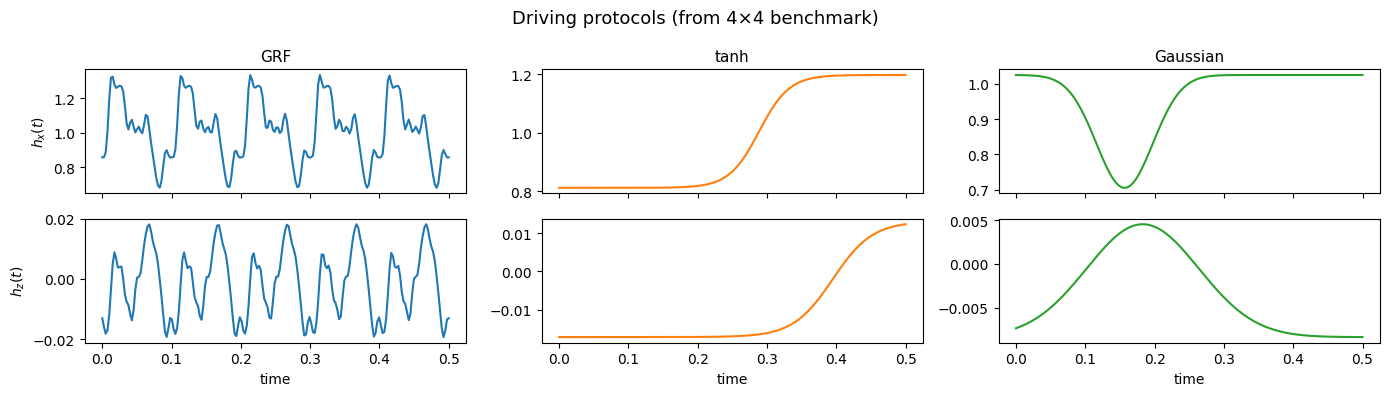

In [53]:
# ── Protocol preview ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex=True)
for col, proto in enumerate(PROTOCOLS):
    h = dmrg[proto]["h"]
    axes[0, col].plot(time_grid, h[:, 0], color=COLORS[col])
    axes[1, col].plot(time_grid, h[:, 1], color=COLORS[col])
    axes[0, col].set_title(proto, fontsize=11)
axes[0, 0].set_ylabel(r"$h_x(t)$")
axes[1, 0].set_ylabel(r"$h_z(t)$")
for ax in axes[1]:
    ax.set_xlabel("time")
fig.suptitle("Driving protocols (from 4×4 benchmark)", fontsize=13)
fig.tight_layout()
plt.show()

In [54]:
# -- Conditional autoregressive sampler ---------------------------------------

@eqx.filter_jit
def sample_given_beta(key, model_ref, ctx, beta_bits_snake, n_samples):
    """Sample alpha ~ |U(alpha | beta, t)|^2 for a fixed Z-basis initial state beta.

    The autoregressive decoder predicts tokens sigma_i = 2*alpha_i + beta_i, so
    at each site i the valid token values are {beta_i, 2+beta_i}.

    Returns
    -------
    sigmas : (n_samples, n_spins) int32
    """
    n_sp = beta_bits_snake.shape[0]
    ctx_batch = jnp.broadcast_to(ctx[None], (n_samples, ctx.shape[0], ctx.shape[1]))

    # Initialise: sigma_i = 0*2 + beta_i = beta_i  (alpha_i = 0)
    sigmas = jnp.broadcast_to(beta_bits_snake[None, :].astype(jnp.int32), (n_samples, n_sp))

    # token % 2 == beta_i  selects valid tokens
    token_beta = jnp.array([0, 1, 0, 1], dtype=jnp.int32)

    def body(carry, i):
        s, rng = carry
        logits = model_ref.logits_from_tokens(s, ctx_batch)[:, i, :]  # (n_samples, 4)
        beta_i = beta_bits_snake[i]
        valid  = (token_beta == beta_i)
        masked = jnp.where(valid[None, :], logits, jnp.full_like(logits, -1e9))
        rng, sub = random.split(rng)
        s_i = random.categorical(sub, masked).astype(jnp.int32)
        s   = s.at[:, i].set(s_i)
        return (s, rng), None

    (sigmas, _), _ = lax.scan(body, (sigmas, key), jnp.arange(n_sp, dtype=jnp.int32))
    return sigmas


# -- Observable estimator from sampled tokens ----------------------------------

@eqx.filter_jit
def estimate_obs_mc(sigmas, ctx, model_ref, bi, bj, h_x_t, h_z_t):
    """Estimate mx, mz, zz, energy via Monte Carlo from sampled alpha states.

    sigmas : (n_samples, n_spins) int32   tokens 2*alpha + beta
    ctx    : (ctx_tokens, embed_dim)
    bi, bj : bond index arrays (snake order)
    h_x_t, h_z_t : scalar float32  field values at this time step

    Returns mx, mz, zz, energy : float32 scalars
    """
    n_s, n_sp = sigmas.shape
    ctx_batch = jnp.broadcast_to(ctx[None], (n_s, ctx.shape[0], ctx.shape[1]))

    alpha_bits = sigmas // 2
    alpha_pm   = 1.0 - 2.0 * alpha_bits.astype(jnp.float32)   # +/-1

    mz = jnp.mean(alpha_pm)
    zz = jnp.mean(alpha_pm[:, bi] * alpha_pm[:, bj])

    log_u = model_ref.log_psi_from_tokens(sigmas, ctx_batch)

    def ratio_fn(i):
        s_flip  = lp.sigma_flip_alpha(sigmas, i)
        lp_flip = model_ref.log_psi_from_tokens(s_flip, ctx_batch)
        return jnp.real(jnp.exp(lp_flip - log_u))

    all_ratios = jax.vmap(ratio_fn)(jnp.arange(n_sp, dtype=jnp.int32))
    mx = jnp.mean(jnp.sum(all_ratios, axis=0)) / float(n_sp)

    n_bonds = float(bi.shape[0])
    energy  = -lp.J_zz * (n_bonds / float(n_sp)) * zz - h_z_t * mz - h_x_t * mx

    return mx, mz, zz, energy


print("Sampling and observable functions compiled (JIT on first call).")

Sampling and observable functions compiled (JIT on first call).


In [55]:
# Load pre-computed predictions from NPZ if available,
# otherwise run the full MC benchmark (requires ~10 min).
NPZ_RESULTS = Path("6by6_results.npz")

if NPZ_RESULTS.exists():
    _d = np.load(str(NPZ_RESULTS))
    results = {}
    for proto in PROTOCOLS:
        results[proto] = {
            "mx_pred":     _d[f"{proto}_mx_pred"],
            "mz_pred":     _d[f"{proto}_mz_pred"],
            "zz_pred":     _d[f"{proto}_zz_pred"],
            "energy_pred": _d[f"{proto}_energy_pred"],
        }
    print(f"Loaded predictions from {NPZ_RESULTS}")
else:
    results = {}  # proto -> dict of model predictions

    for proto in PROTOCOLS:
        d    = dmrg[proto]
        h    = jnp.asarray(d["h"], dtype=jnp.float32)           # (T_STEPS, 2)
        beta = jnp.asarray(d["bits_snake"], dtype=jnp.int32)    # (n_spins,)

        m_traj, _ = model.encode_field(h[None, :, :])           # (1, T_STEPS, ctx, d)
        m_traj = m_traj[0]                                      # (T_STEPS, ctx, d)

        mx_list, mz_list, zz_list, energy_list = [], [], [], []
        rng = random.PRNGKey(42)

        for t_idx in range(T_STEPS):
            rng, subkey = random.split(rng)
            ctx_t  = m_traj[t_idx]
            h_x_t  = jnp.float32(d["hx"][t_idx])
            h_z_t  = jnp.float32(d["hz"][t_idx])
            sigmas = sample_given_beta(subkey, model, ctx_t, beta, N_SAMPLES)
            mx, mz, zz, energy = estimate_obs_mc(
                sigmas, ctx_t, model, bonds_i_jnp, bonds_j_jnp, h_x_t, h_z_t
            )
            mx_list.append(float(mx))
            mz_list.append(float(mz))
            zz_list.append(float(zz))
            energy_list.append(float(energy))

            if t_idx % 20 == 0 or t_idx == T_STEPS - 1:
                print(f"  [{proto}] t={time_grid[t_idx]:.3f} ({t_idx+1}/{T_STEPS})"
                      f"  mx={mx:.4f}  mz={mz:.4f}  zz={zz:.4f}  E={energy:.4f}")

        results[proto] = {
            "mx_pred":     np.array(mx_list,     dtype=np.float32),
            "mz_pred":     np.array(mz_list,     dtype=np.float32),
            "zz_pred":     np.array(zz_list,     dtype=np.float32),
            "energy_pred": np.array(energy_list, dtype=np.float32),
        }
        print(f"  [{proto}] done.\n")

    print("All benchmarks complete.")

# Verify we have energy for all protocols
for proto in PROTOCOLS:
    ep = results[proto]["energy_pred"]
    print(f"{proto}: energy_pred[-1]={ep[-1]:.4f}")

Loaded predictions from 6by6_results.npz
GRF: energy_pred[-1]=0.1300
tanh: energy_pred[-1]=0.3378
Gaussian: energy_pred[-1]=-0.1065


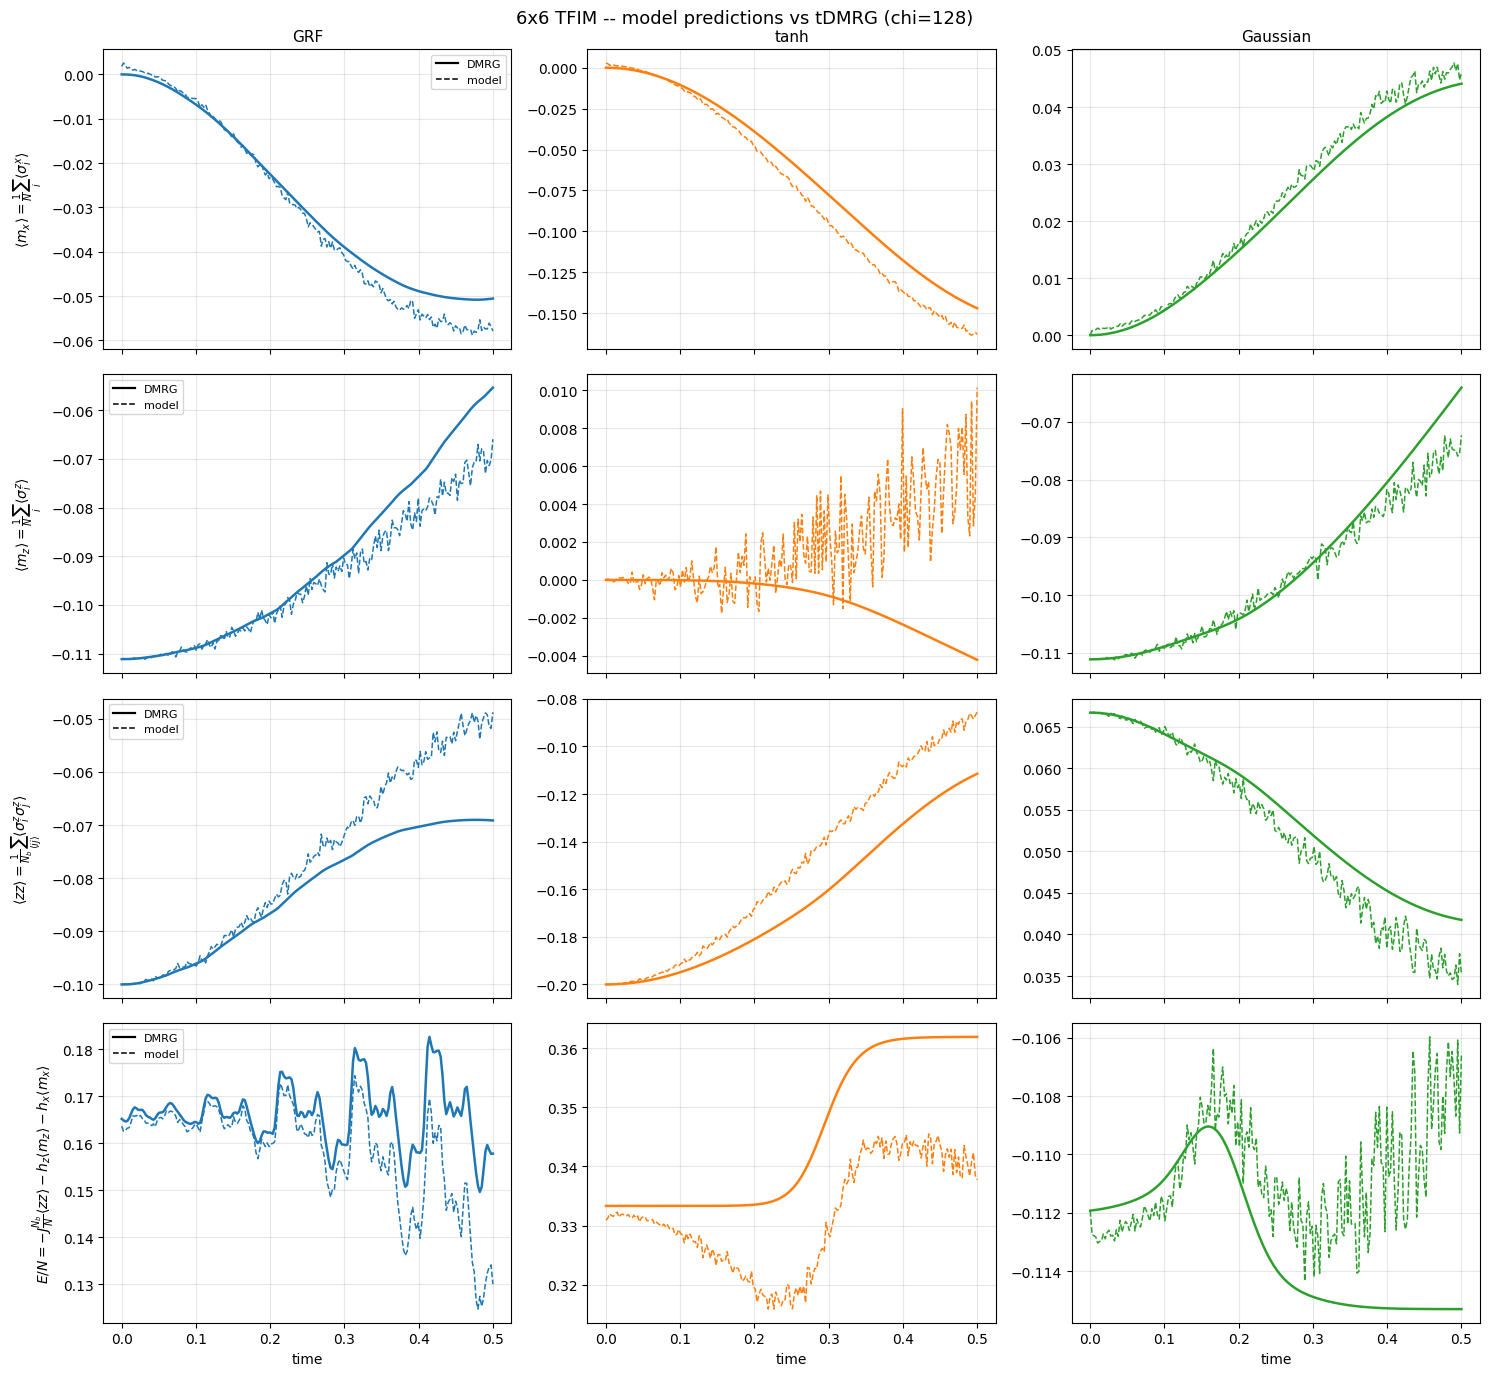

Saved -> 6by6_observables.pdf


In [56]:
proxy_lines = [
    Line2D([0], [0], color="k", lw=1.6,          label="DMRG"),
    Line2D([0], [0], color="k", lw=1.1, ls="--", label="model"),
]

obs_cfg = [
    ("mx",     r"$\langle m_x \rangle = \frac{1}{N}\sum_i\langle\sigma^x_i\rangle$"),
    ("mz",     r"$\langle m_z \rangle = \frac{1}{N}\sum_i\langle\sigma^z_i\rangle$"),
    ("zz",     r"$\langle zz \rangle = \frac{1}{N_b}\sum_{\langle ij\rangle}\langle\sigma^z_i\sigma^z_j\rangle$"),
    ("energy", r"$E/N = -J\frac{N_b}{N}\langle zz\rangle - h_z\langle m_z\rangle - h_x\langle m_x\rangle$"),
]

fig, axes = plt.subplots(len(obs_cfg), len(PROTOCOLS),
                         figsize=(5 * len(PROTOCOLS), 3.5 * len(obs_cfg)),
                         sharex=True)
axes = np.array(axes).reshape(len(obs_cfg), len(PROTOCOLS))

for col, proto in enumerate(PROTOCOLS):
    d   = dmrg[proto]
    res = results[proto]
    for row, (obs_key, ylabel) in enumerate(obs_cfg):
        ax = axes[row, col]
        ax.plot(time_grid, d[obs_key],             color=COLORS[col], lw=1.8, label="DMRG")
        ax.plot(time_grid, res[f"{obs_key}_pred"], color=COLORS[col], lw=1.1, ls="--", label="model")
        ax.grid(alpha=0.3)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=10)
            ax.legend(handles=proxy_lines, fontsize=8, loc="best")
        if row == 0:
            ax.set_title(proto, fontsize=11)
        if row == len(obs_cfg) - 1:
            ax.set_xlabel("time")

fig.suptitle("6x6 TFIM -- model predictions vs tDMRG (chi=128)", fontsize=13)
fig.tight_layout()
#plt.savefig("6by6_observables.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved -> 6by6_observables.pdf")

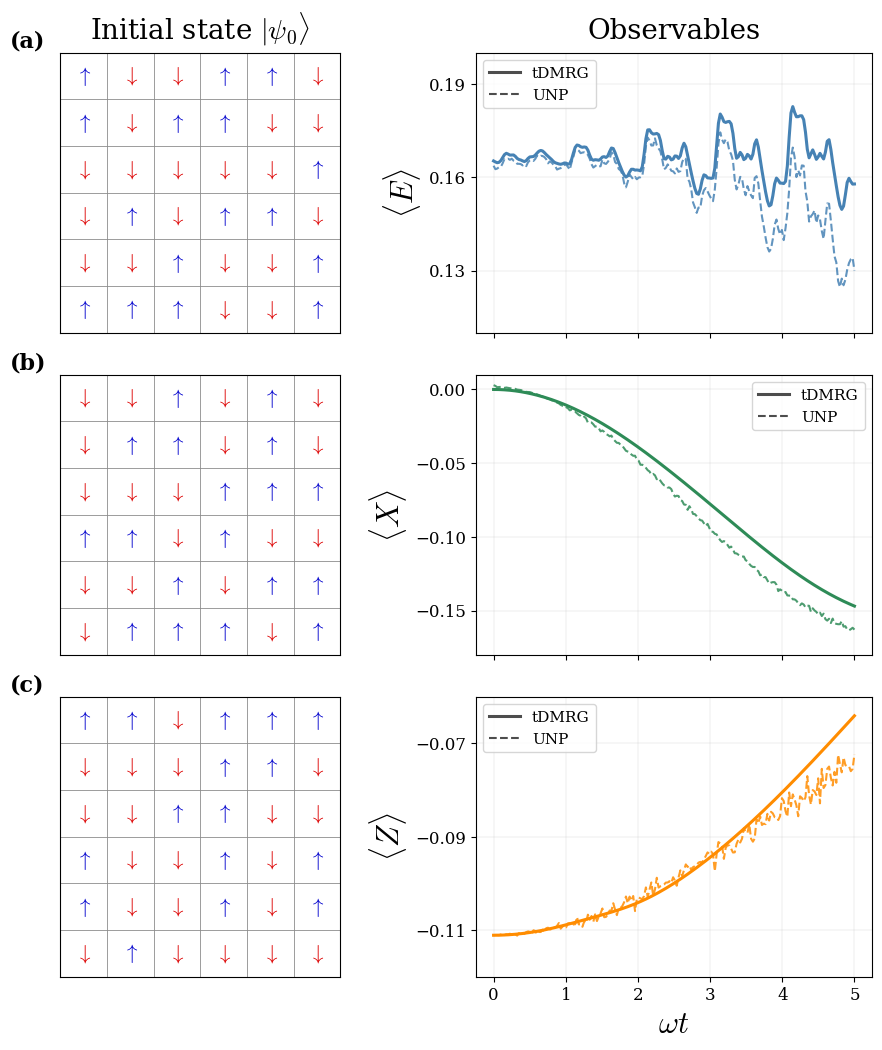

Saved -> 6by6_overview.pdf


In [81]:
import matplotlib as mpl

plt.rcParams.update({
    "text.usetex":      False,
    "mathtext.fontset": "cm",
    "font.family":      "serif",
    "font.size":        14,
    "axes.titlesize":   15,
    "axes.labelsize":   14,
    "xtick.labelsize":  12,
    "ytick.labelsize":  12,
    "legend.fontsize":  11,
})

tg = time_grid * 10

COLOR_UP   = "#0000CD"
COLOR_DOWN = "#DD0000"

# Each row: (protocol, color, observable_key, observable_label)
ROW_CONFIGS = [
    ("GRF",      "steelblue",  "energy", r"$\langle E \rangle$"),
    ("tanh",     "seagreen",   "mx", r"$\langle X \rangle$"),
    ("Gaussian", "darkorange", "mz", r"$\langle Z \rangle$"),
]

ROW_PANEL_LABELS = ["(a)", "(b)", "(c)"]


def plot_spin_config_6x6(ax, bits_rowmajor, lx=6, ly=6):
    for i, bit in enumerate(bits_rowmajor):
        x = i % lx
        y = (ly - 1) - (i // lx)
        char  = r"$\uparrow$" if bit == 0 else r"$\downarrow$"
        color = COLOR_UP if bit == 0 else COLOR_DOWN
        ax.text(x, y, char, ha="center", va="center",
                fontsize=15, color=color, fontweight="bold")
    for b in np.arange(-0.5, lx, 1.0):
        ax.axvline(b, color="0.55", lw=0.6, zorder=0)
        ax.axhline(b, color="0.55", lw=0.6, zorder=0)
    ax.set_xlim(-0.5, lx - 0.5)
    ax.set_ylim(-0.5, ly - 0.5)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_linewidth(0.8)


fig, axes = plt.subplots(
    3, 2, figsize=(11, 12),
    gridspec_kw={"wspace": 0.25, "hspace": 0.15, "width_ratios": [1.0, 1.1]},
)

axes[0, 0].set_title(r"Initial state $|\psi_0\rangle$", fontsize=20, pad=10)
axes[0, 1].set_title("Observables", fontsize=20, pad=10)

from matplotlib.lines import Line2D
style_handles = [
    Line2D([0], [0], color="0.3", lw=2.2,          label="tDMRG"),
    Line2D([0], [0], color="0.3", lw=1.5, ls="--", label="UNP"),
]

for row, (proto, color, obs_key, obs_label) in enumerate(ROW_CONFIGS):
    is_bottom = (row == 2)
    d   = dmrg[proto]
    res = results[proto]

    # left: spin configuration
    ax_spin = axes[row, 0]
    plot_spin_config_6x6(ax_spin, d["bits_rowmajor"])
    #ax_spin.set_ylabel(proto, fontsize=13, labelpad=6)
    ax_spin.text(-0.18, 1.08, ROW_PANEL_LABELS[row],
                 transform=ax_spin.transAxes, fontsize=16, fontweight="bold",
                 va="top", ha="left")

    # right: one observable, one protocol
    ax_obs = axes[row, 1]
    ax_obs.plot(tg, d[obs_key],              color=color, lw=2.2,          label="tDMRG")
    ax_obs.plot(tg, res[f"{obs_key}_pred"],  color=color, lw=1.5, ls="--", alpha=0.85, label="UNP")
    ax_obs.set_ylabel(obs_label, fontsize=22)
    ax_obs.legend(handles=style_handles, loc="best")
    ax_obs.grid(True, lw=0.3, alpha=0.5)
    if is_bottom:
        ax_obs.set_xlabel(r"$\omega t$", fontsize=22)
    else:
        ax_obs.tick_params(labelbottom=False)

axes[0,1].set_ylim([0.11, 0.20])
axes[0,1].set_yticks([0.13, 0.16, 0.19])
axes[1,1].set_ylim([-0.18, 0.01])
axes[1,1].set_yticks([0, -0.05, -0.1, -0.15])
axes[2,1].set_ylim([-0.12, -0.06])
axes[2,1].set_yticks([-0.07, -0.09, -0.11])


#plt.savefig("6by6_overview.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Saved -> 6by6_overview.pdf")

plt.rcParams.update(mpl.rcParamsDefault)

In [58]:
print(f"{'Protocol':<12} {'MAE mx':>9}  {'MAE mz':>9}  {'MAE zz':>9}  {'MAE E':>9}  "
      f"{'RMSE mx':>10}  {'RMSE mz':>10}  {'RMSE zz':>10}  {'RMSE E':>10}")
print("-" * 100)
for proto in PROTOCOLS:
    d   = dmrg[proto]
    res = results[proto]
    metrics = {}
    for obs_key in ("mx", "mz", "zz", "energy"):
        ref  = d[obs_key]
        pred = res[f"{obs_key}_pred"]
        metrics[obs_key] = (
            float(np.mean(np.abs(ref - pred))),
            float(np.sqrt(np.mean((ref - pred) ** 2))),
        )
    mae_mx, rmse_mx = metrics["mx"]
    mae_mz, rmse_mz = metrics["mz"]
    mae_zz, rmse_zz = metrics["zz"]
    mae_e,  rmse_e  = metrics["energy"]
    print(f"{proto:<12}"
          f"  {mae_mx:>9.5f}"
          f"  {mae_mz:>9.5f}"
          f"  {mae_zz:>9.5f}"
          f"  {mae_e:>9.5f}"
          f"  {rmse_mx:>10.5f}"
          f"  {rmse_mz:>10.5f}"
          f"  {rmse_zz:>10.5f}"
          f"  {rmse_e:>10.5f}")

Protocol        MAE mx     MAE mz     MAE zz      MAE E     RMSE mx     RMSE mz     RMSE zz      RMSE E
----------------------------------------------------------------------------------------------------
GRF             0.00271    0.00374    0.00602    0.00783     0.00355     0.00572     0.00864     0.01105
tanh            0.01101    0.00307    0.01496    0.01337     0.01311     0.00461     0.01765     0.01509
Gaussian        0.00190    0.00217    0.00258    0.00272     0.00226     0.00347     0.00342     0.00358


In [59]:
save_dict = {"time_grid": time_grid}
for proto in PROTOCOLS:
    d   = dmrg[proto]
    res = results[proto]
    p   = proto
    save_dict[f"{p}_hx"]          = d["hx"]
    save_dict[f"{p}_hz"]          = d["hz"]
    for key in ("mx", "mz", "zz", "ent", "energy"):
        save_dict[f"{p}_{key}_dmrg"] = d[key]
    for key in ("mx", "mz", "zz", "energy"):
        save_dict[f"{p}_{key}_pred"] = res[f"{key}_pred"]

np.savez("6by6_results.npz", **save_dict)
print("Saved -> 6by6_results.npz")
print("Keys:", sorted(save_dict.keys()))

Saved -> 6by6_results.npz
Keys: ['GRF_energy_dmrg', 'GRF_energy_pred', 'GRF_ent_dmrg', 'GRF_hx', 'GRF_hz', 'GRF_mx_dmrg', 'GRF_mx_pred', 'GRF_mz_dmrg', 'GRF_mz_pred', 'GRF_zz_dmrg', 'GRF_zz_pred', 'Gaussian_energy_dmrg', 'Gaussian_energy_pred', 'Gaussian_ent_dmrg', 'Gaussian_hx', 'Gaussian_hz', 'Gaussian_mx_dmrg', 'Gaussian_mx_pred', 'Gaussian_mz_dmrg', 'Gaussian_mz_pred', 'Gaussian_zz_dmrg', 'Gaussian_zz_pred', 'tanh_energy_dmrg', 'tanh_energy_pred', 'tanh_ent_dmrg', 'tanh_hx', 'tanh_hz', 'tanh_mx_dmrg', 'tanh_mx_pred', 'tanh_mz_dmrg', 'tanh_mz_pred', 'tanh_zz_dmrg', 'tanh_zz_pred', 'time_grid']
